# 3장 2강: SDK 개발 환경 구성과 연결 테스트
## 3. Supabase Client 초기화

In [ ]:
# .env 파일의 값을 환경변수로 불러오기
import os
from supabase import create_client

url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_PUBLISHABLE_KEY')

# Client 초기화
supabase = create_client(url, key)
print(supabase)


## 4. 연결 테스트와 응답·오류 객체 확인

# 3장 3강: SDK 기반 데이터 생성 구현

## 1. SDK insert 구조

In [ ]:
# user 추가
response = (
    supabase.table("users")
    .insert(
        {
            "email": "user03@test.org"
        }
    )
    .execute()
)


In [ ]:
response

In [ ]:
response.data

In [ ]:
#document 추가
response = (
    supabase.table("documents")
    .insert({
        "title": "두 번째 문서",
        "content": "본문 내용",
        "user_id": "0e4cd427-bbb2-4ede-a1fa-62d3e0bb09dc"
    })
    .execute()
)
response.data

In [ ]:
# 회원 목록 조회
response = (
    supabase.table("users")
    .select("*")
    .execute()
)
response.data

In [ ]:
response = (
    supabase.table("users")
    .select("*")
    .ilike("email", "USER02%")
    .execute()
)

print(response)
id, email, created_at = response.data[0]
print("id:", id, "email:", email, "created_at:", created_at)

In [ ]:
response = (
    supabase.table("users")
    .select("*")
    .ilike("email", "USER02%")
    .single() # record 무조건 1개 나와야 하고 아니면 예외발생(API Error), 반환값은 딕셔너리
    .execute()
)


users = response.data
print(users)

In [ ]:
response = (
    supabase.table("users")
    .select("*")
    .ilike("email", "USER%")
    .limit(1) # limit the num of rows returned
    .offset(1) # 1번 인덱스부터 조회
    .maybe_single() # 0~1개. 조회된 결과 없어도 오류 안남. 1개 있으면 1개 반환, 0개면 None 반환
    .execute()
)

print(response)

In [ ]:
response = (
    supabase.table("users")
    .select("*")
    .order("email", desc=True)
    .execute()
)

response.data

In [ ]:
# LEFT JOIN
response = (
    supabase.table("documents")
    .select("id, title, content, users(id, email)")
    .execute()
)
response.data

In [ ]:
# INNER JOIN
response = (
    supabase.table("documents")
    .select("id, title, content, users!inner(id, email)")
    .ilike("users.email", "user%")
    .execute()
)
response.data

## 2. 입력값과 DB 컬럼 매핑

## 3. 생성 결과와 오류 응답 처리

In [ ]:
create_document(None, "본문 내용입니다.", 1)

# 3장 4강: SDK 기반 데이터 조회 구현

## 1. SDK select 구조

## 2. 조건 필터링: eq, order, limit

## 3. 사용자별 조회와 결과 리스트 처리

# 3장 5강: SDK 기반 데이터 수정·삭제 구현

## 1. SDK update 구조

In [ ]:
response = (
    supabase.table("documents")
    .select("*")
    .execute()
)
response.data

In [ ]:
response = (
    supabase.table("documents")
    .update({
        "title": "첫 번째 문서(수정)"
    })
    .eq("id", "7c2ccf7c-54fd-4c25-941d-c4402078efa0") # WHERE 과 같은 역할
    .execute()
)

## 2. SDK delete 구조

In [ ]:
respose = (
    supabase.table("users")
    .delete()
    .eq("id", "c73ce98c-da11-4c73-82bc-17df6af13081")
    .execute()
)
response.data

In [ ]:
respose = (
    supabase.table("users")
    .select("*")
    .execute()
)
response.data

## 3. 수정·삭제 후 검증과 오류 처리

In [ ]:
# 검증: 상태가 잘 바뀌었는지 다시 조회


# 3장 6강: Supabase Authentication 기본 흐름

## 2. 이메일 기반 회원가입과 로그인

In [ ]:
key = os.getenv("SUPABASE_ANON_KEY")
print(key)

supabase = create_client(url, key)
print(supabase)

"""
supabase.auth : 인증(로그인) / 인가(접근 제한) 관련 메서드 가지고 있는 객체

테이블명: auth.users
"""

# 회원가입
response = (
supabase.auth.sign_up({
    "email": "user01@test.org",
    "password": "password1234",
    "phone": "010-1000-1000"
})
)

response


In [ ]:
# 로그인
response = supabase.auth.sign_in_with_password({
    "email":"user01@test.org",
    "password":"password1234"
})
response.user 
# 식별된 정보 유지

## 3. 세션, 로그아웃, user 객체

In [ ]:
# 현재 로그인된 사용자 확인
user = supabase.auth.get_user() # 현재 로그인한 사용자 정보, 있으면 로그인 상태, none이면 미인증상태

if user:
    print("로그인 상태:",user)
else:
    print("미로그인 상태")

In [ ]:
user_response = supabase.auth.get_user()

user_id = user_response.user.id

response = (
    supabase.table("documents")
    .insert({
        "title": "첫 번째 문서",
        "content": "문서 내용입니다.",
        "user_id": user_id # 현재 로그인한 사용자에게서 가져오는 방식
    })
    .execute()
)

In [ ]:
# authenticaion UID = auth.user.id --> ddb04cad-846a-4902-b622-12dd0035f2ae

# authentication UID로 document 추가
response = (
    supabase.table("documents")
    .insert({
        "title": "첫 번째 문서",
        "content": "문서 내용입니다.",
        "user_id": "ddb04cad-846a-4902-b622-12dd0035f2ae"
    })
    .execute()
)


In [ ]:
# 로그아웃
supabase.auth.sign_out()

## 4. 사용자 ID와 테이블 데이터 연결

# 3장 7강: 사용자별 데이터 접근과 권한 관리

RLS (Row Level Security)
- CRUD: 회원의 권한을 체크 (DB): select, insert, update, delete
- 행 단위로 접근을 통제함
- 통제: 어떤 사용자가 어떤 행에 접근할 수 있는지 데이터베이스가 직접 검사



In [ ]:
#-- documents 테이블에 RLS 활성화
alter table documents enable row level security;

#-- 본인 행만 SELECT 허용하는 정책
create policy "본인 문서만 조회"
on documents
for select
using (auth.uid() = user_id); # auth.uid(): 현재 요청을 보낸 로그인 사용자 id

In [ ]:
# -- 본인 데이터에 대해 모든 작업(SELECT, INSERT, UPDATE, DELETE) 허용
create policy "본인 문서 전체 관리"
on documents
for all # 한번에 모든 CRUD 권한 부여하기 
to authenticated
using (auth.uid() = user_id) # 이미 존재하는 데이터에 대한 통제시 내 데이터인지 검사
with check (auth.uid() = user_id); # 새로 추가될 데이터 혹은 수정될 데이터에 대한 통제시 검사

In [ ]:
# 작업별로 개별 정책 분리하기
#-- 생성 (INSERT): 저장할 데이터의 user_id가 본인인지 확인
create policy "본인 문서 생성"
on documents for insert to authenticated
with check (auth.uid() = user_id);

#-- 조회 (SELECT): 기존 데이터의 user_id가 본인인지 확인
create policy "본인 문서 조회"
on documents for select to authenticated
using (auth.uid() = user_id);

#-- 수정 (UPDATE): 수정할 대상과 수정 후 데이터 모두 본인인지 확인
create policy "본인 문서 수정"
on documents for update to authenticated
using (auth.uid() = user_id)
with check (auth.uid() = user_id);

#-- 삭제 (DELETE): 삭제할 대상이 본인 데이터인지 확인
create policy "본인 문서 삭제"
on documents for delete to authenticated
using (auth.uid() = user_id);

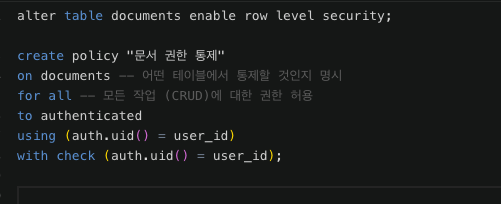
- supabase sql 예시

In [28]:
# 가입
supabase.auth.sign_up({
    "email": "user02@test.org",
    "password": "password1234"
})

AuthResponse(user=User(id='3dd35661-cb47-46e4-95c2-f48dd08d3987', app_metadata={'provider': 'email', 'providers': ['email']}, user_metadata={'email': 'user02@test.org', 'email_verified': True, 'phone_verified': False, 'sub': '3dd35661-cb47-46e4-95c2-f48dd08d3987'}, aud='authenticated', confirmation_sent_at=None, recovery_sent_at=None, email_change_sent_at=None, new_email=None, new_phone=None, invited_at=None, action_link=None, email='user02@test.org', phone='', created_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 153890, tzinfo=TzInfo(0)), confirmed_at=None, email_confirmed_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 188929, tzinfo=TzInfo(0)), phone_confirmed_at=None, last_sign_in_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 193885, tzinfo=TzInfo(0)), role='authenticated', updated_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 203494, tzinfo=TzInfo(0)), identities=[UserIdentity(id='3dd35661-cb47-46e4-95c2-f48dd08d3987', identity_id='7cb71105-3af3-4696-b470-ed8c2c2b1f7e', user_id='3dd356

In [29]:
# 로그인
supabase.auth.sign_in_with_password({
    "email": "user02@test.org",
    "password": "password1234"
})

AuthResponse(user=User(id='3dd35661-cb47-46e4-95c2-f48dd08d3987', app_metadata={'provider': 'email', 'providers': ['email']}, user_metadata={'email': 'user02@test.org', 'email_verified': True, 'phone_verified': False, 'sub': '3dd35661-cb47-46e4-95c2-f48dd08d3987'}, aud='authenticated', confirmation_sent_at=None, recovery_sent_at=None, email_change_sent_at=None, new_email=None, new_phone=None, invited_at=None, action_link=None, email='user02@test.org', phone='', created_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 153890, tzinfo=TzInfo(0)), confirmed_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 188929, tzinfo=TzInfo(0)), email_confirmed_at=datetime.datetime(2026, 9, 10, 2, 12, 34, 188929, tzinfo=TzInfo(0)), phone_confirmed_at=None, last_sign_in_at=datetime.datetime(2026, 9, 10, 2, 13, 35, 909492, tzinfo=TzInfo(0)), role='authenticated', updated_at=datetime.datetime(2026, 9, 10, 2, 13, 35, 914403, tzinfo=TzInfo(0)), identities=[UserIdentity(id='3dd35661-cb47-46e4-95c2-f48dd08d3987', iden

In [30]:
response = (
    supabase.table("documents")
            .select("*")
            .execute()
)
response.data

[]

- user02로 로그인한 상태
- user02 문서 작성한게 없음 -> RLS 정책(자신이 쓴 글만 볼 수 있음)으로 보이지 않음
- user01로 로그인하면, 작성한 문서 목록이 보임

In [31]:
# 로그인 user01
supabase.auth.sign_in_with_password({
    "email": "user01@test.org",
    "password": "password1234"
})

AuthResponse(user=User(id='ddb04cad-846a-4902-b622-12dd0035f2ae', app_metadata={'provider': 'email', 'providers': ['email']}, user_metadata={'email': 'user01@test.org', 'email_verified': True, 'phone_verified': False, 'sub': 'ddb04cad-846a-4902-b622-12dd0035f2ae'}, aud='authenticated', confirmation_sent_at=None, recovery_sent_at=None, email_change_sent_at=None, new_email=None, new_phone=None, invited_at=None, action_link=None, email='user01@test.org', phone='', created_at=datetime.datetime(2026, 9, 9, 3, 40, 5, 899827, tzinfo=TzInfo(0)), confirmed_at=datetime.datetime(2026, 9, 9, 3, 40, 5, 918617, tzinfo=TzInfo(0)), email_confirmed_at=datetime.datetime(2026, 9, 9, 3, 40, 5, 918617, tzinfo=TzInfo(0)), phone_confirmed_at=None, last_sign_in_at=datetime.datetime(2026, 9, 10, 2, 16, 30, 339943, tzinfo=TzInfo(0)), role='authenticated', updated_at=datetime.datetime(2026, 9, 10, 2, 16, 30, 361308, tzinfo=TzInfo(0)), identities=[UserIdentity(id='ddb04cad-846a-4902-b622-12dd0035f2ae', identity_i

In [1]:
response = (
    supabase.table("documents")
            .select("*")
            .execute()
)
response.data

NameError: name 'supabase' is not defined

## 2. user_id 기반 필터링

In [ ]:


# 본인 문서만 조회


# 3장 8강: SDK 기반 미니 과제 - 사용자별 문서 CRUD

## 2. Auth와 user_id 연결

In [ ]:
import os
from supabase import create_client

url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_ANON_KEY")

supabase = create_client(url, key)
print(supabase)

supabase.auth.sign_in_with_password({
    "email": "user01@test.org",
    "password": "password1234"
})

user = supabase.auth.get_user().user
user_id = user.id
print(user)

# 생성: 로그인 사용자의 문서
response = (
    supabase.table("documents")
            .insert({
                "title":"두 번째 문서",
                "content":"두 번째 문서 내용입니다.",
                "user_id":user_id
            })
            .execute()
)

print(response)
# 조회: 본인 문서만


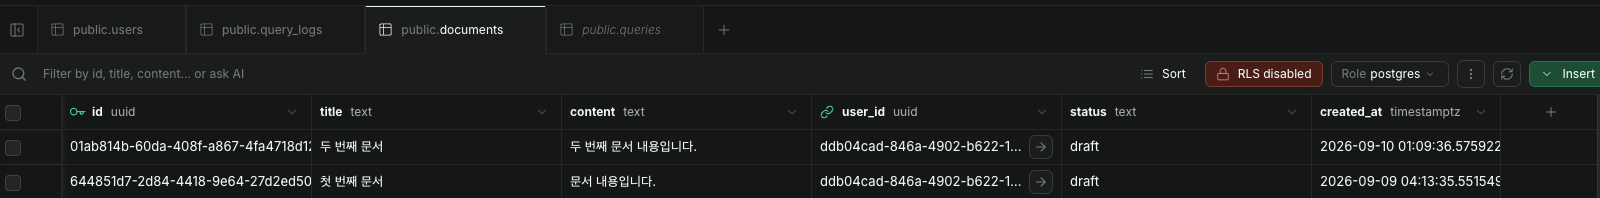

In [ ]:
# 위의 내용을 함수로 정의하기 (공통적 처리 가능하도록)
# CRUD class

class AI_log:
    def __init__(self):
        user = supabase.auth.get_user()
        if not user:
            raise PermissionError("로그인이 필요합니다.")

        self.user = user.user # user정보 확인 가능

    def create_documents(self, title, content):
        response = (
            supabase.table("documents")
                    .insert({
                        "title": title,
                        "content": content,
                        "user_id": self.user.id
                    })
                    .execute()
        )

        return response.data

    def get_my_documents(self):
        response = (
            supabase.table("documents")
                    .select("*")
                    .eq("user_id", self.user.id)
                    .execute()
        )

        return response.data

In [ ]:
ai_log = AI_log()

ai_log.create_documents("세 번째 문서", "CRUD class로 만든 세 번째 다큐먼트 본문 내용입니다.")

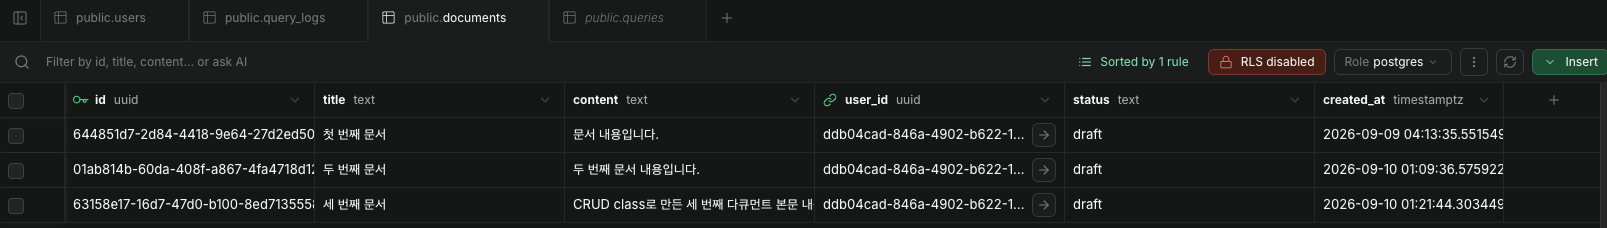

In [ ]:
ai_log.get_my_documents()

## 3. 응답·오류 처리와 코드 구조 정리